# BRICS fragment toxicity analysis

Standalone notebook for the BRICS fragment interpretability analysis (extracted from `interp-avg.ipynb`, without the average-molecule / average-taxid ablations).

**How to run it in two places:**

- **On the GPU server (compute):** run everything down to and including the *Compute* cell. It saves all results to `outputs/reports/brics_fragment_analysis/<timestamp>/`.
- **Locally (plots):** copy that run folder here, then run only the **Setup imports** cell, the **BRICS config**, both **function** cells, and the **Plots & analysis** cells. You can SKIP the data-loading and model cells — the plots read from the saved CSVs.

## Setup: data, graphs, predictions, model builder

In [1]:
# N_SAMPLES = 10000
N_SAMPLES = None
random_state = 11
fold_id = 0

FILTERS = {
    "duration_unit": ["h"],
    "effect": ["MOR", "POP", "GRO", "BEH", "REP", "ITX", "PHY", "DVP", "MPH"],
}

SPLIT_SALTS = False
REMOVE_LONE = False
REMOVE_METALS = False

MAX_CONC_VALUE = 10000
DURATION_FILL_VALUE = 1e-6
MAX_DURATION_HOURS = 9000.0

%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    possible = Path.cwd() / "vollmers/gnn-thesis/gnn-thesis"
    if (possible / "src").exists():
        PROJECT_ROOT = possible

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch_geometric.loader import DataLoader
from torch_geometric.utils.smiles import from_smiles

from src.data.io import load_data
from src.data.cleaning import process_data, print_mol_types
from src.data.graph_building import build_graphs
from src.data.metadata import sequential_encoder, build_config
from src.data.cleaning import fragment_count, is_salt, has_metal, is_single_node
from src.data.splitting import butina_split, show_split_info
from src.data.sampling import LoadData, show_loader_info, display_sampling_effect
from src.training.loops import train
from src.visualization.training_plots import  plot_training, plot_training_metrics, plot_group_training


pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

print("Imports imported")


/home/vollmers/.conda/envs/gnn-m/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports imported


In [2]:
DATA_PATH = PROJECT_ROOT / "Data" / "toxicity_all.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Data file not found: {DATA_PATH}")

print(f"Data path: {DATA_PATH}")

df_all = load_data(DATA_PATH)

df_processed = process_data(
    df_all,
    n_samples=N_SAMPLES,
    random_state=random_state,
    filters=FILTERS,
    require_duration=False,
    require_taxid=True,
    split_salts=SPLIT_SALTS,
    remove_lone=REMOVE_LONE,
    remove_metals=REMOVE_METALS,
    max_conc_value=MAX_CONC_VALUE,
    duration_fill_value=DURATION_FILL_VALUE,
    max_duration_hours=MAX_DURATION_HOURS,
    log_transform_duration=True,
    keep_duration_raw=True,
)

df_processed


Data path: /home/vollmers/gnn-thesis/Data/toxicity_all.csv
Filters
conc > 0 and <= 10000
True: 0.990
duration_unit: ['h']
True: 0.980
effect: ['MOR', 'POP', 'GRO', 'BEH', 'REP', 'ITX', 'PHY', 'DVP', 'MPH']
True: 0.981
require_taxid: True
True: 0.995
duration <= 9000.0 h or missing
True: 0.986

Loaded and masked training data
Rows in full data: 561,100
Rows after mask: 525,852
Rows before preprocessing: 525,852
Rows after preprocessing:  525,852
Rows removed: 0


,SK_unique_id,species_common_name,species_latin_name,CAS,chemical_name,conc_unit,conc,duration,duration_unit,effect,endpoint,SMILES,organism_lifestage,administration_route,species_sci_name,taxid,superkingdom,kingdom,phylum,subphylum,class,order,family,genus,species,species_group,log10c,duration_raw
0,RTECS7,mouse,Mus musculus,108073-64-9,"5H-Pyrrolo(2,1-c)(1,4)benzodiazepin-5-one, 1,2,3,10,11,11a-hexahydro-2-hydro...",mg/kg,36.200,-6.000000,h,MOR,EC50,COC1Nc2ccccc2C(=O)N2CC(O)CC12,adult,fill,mus musculus,10090,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10088.0,10090.0,rodents,1.558709,NaN
1,RTECS41,mouse,Mus musculus,78111-17-8,"Acanthifolicin, 9,10-deepithio-9,10-didehydro-",mg/kg,0.192,-6.000000,h,MOR,EC50,C=C1C(O)C2OC3(CCC(C=CC(C)C4CC(C)=CC5(OC(CC(C)(O)C(=O)O)CCC5O)O4)O3)CCC2OC1C(...,adult,fill,mus musculus,10090,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10088.0,10090.0,rodents,-0.716699,NaN
2,RTECS137,mouse,Mus musculus,4657-93-6,5-Acenaphthenamine,mg/kg,56.000,-6.000000,h,MOR,EC50,Nc1ccc2c3c(cccc13)CC2,adult,fill,mus musculus,10090,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10088.0,10090.0,rodents,1.748188,NaN
3,RTECS140,mouse,Mus musculus,102585-20-6,"5-Acenaphthenamine, 6,7,8,8a-tetrahydro-N-(2-oxazolin-2-yl)-",mg/kg,100.000,-6.000000,h,MOR,EC50,c1cc(NC2=NCCO2)c2c3c1CCC3CCC2,adult,fill,mus musculus,10090,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10088.0,10090.0,rodents,2.000000,NaN
4,RTECS141,rat,Rattus norvegicus,83-32-9,Acenaphthene,mg/kg,600.000,-6.000000,h,MOR,EC50,c1cc2c3c(cccc3c1)CC2,adult,fill,rattus norvegicus,10116,2759.0,33208.0,7711.0,89593.0,40674.0,9989.0,10066.0,10114.0,10116.0,rodents,2.778151,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525847,AQTER1441956,Eelgrass,vallisneria natans,7758-98-7,Sulfuric acid copper(2+) salt (1:1),mg/L,0.041,2.283301,h,GRO,LOEC,O=S(=O)([O-])[O-].[Cu+2],adult,renewal,vallisneria natans,62345,2759.0,33090.0,35493.0,131221.0,3398.0,16360.0,26319.0,26336.0,62345.0,plants,-1.387216,192.0
525848,AQTER1441958,Eelgrass,vallisneria natans,7758-98-7,Sulfuric acid copper(2+) salt (1:1),mg/L,0.640,1.982271,h,GRO,LOEC,O=S(=O)([O-])[O-].[Cu+2],adult,renewal,vallisneria natans,62345,2759.0,33090.0,35493.0,131221.0,3398.0,16360.0,26319.0,26336.0,62345.0,plants,-0.193820,96.0
525849,AQTER1441960,Eelgrass,vallisneria natans,7758-98-7,Sulfuric acid copper(2+) salt (1:1),mg/L,0.160,1.982271,h,GRO,NOEC,O=S(=O)([O-])[O-].[Cu+2],adult,renewal,vallisneria natans,62345,2759.0,33090.0,35493.0,131221.0,3398.0,16360.0,26319.0,26336.0,62345.0,plants,-0.795880,96.0
525850,AQTER1441966,Eelgrass,vallisneria natans,7758-98-7,Sulfuric acid copper(2+) salt (1:1),mg/L,0.640,1.982271,h,GRO,NOEC,O=S(=O)([O-])[O-].[Cu+2],adult,renewal,vallisneria natans,62345,2759.0,33090.0,35493.0,131221.0,3398.0,16360.0,26319.0,26336.0,62345.0,plants,-0.193820,96.0


In [ ]:
from src.data.simple_featurizer import simple_featurizer
from src.data.features_graph import GraphFeaturizer

ATOM_FEATURES = (
    "atomic_num",
    "degree",
    "formal_charge",
    "num_hs",
    "hybridization",
    "is_aromatic",
    "is_in_ring",
    "atomic_mass",
    "period",
    "group",
    "covalent_radius",
    "vdw_radius",
    "is_metal",
)

BOND_FEATURES = (
    "bond_order",
    "is_conjugated",
    "is_in_ring",
    "stereo",
)

graph_featurizer = GraphFeaturizer(ATOM_FEATURES, BOND_FEATURES)

df_processed["features"] = df_processed["SMILES"].apply(graph_featurizer.featurize)

graph_cache = graph_featurizer.get_graph_cache()

from src.data.features_mol import add_molecule_metadata

MOLECULE_CATEGORICAL_COLS = [
    "is_salt",
    "has_metal",
    "is_single_node",
]

MOLECULE_NUMERICAL_COLS = [
    "fragment_count",
    # "mol_weight",
    "log10_mol_weight",
    # "logp",
    # "tpsa",
    # "log10_tpsa_plus1",
    # "h_bond_donor_count",
    # "h_bond_acceptor_count",
    # "heavy_atom_count",
    # "log10_heavy_atom_count_plus1",
    # "hetero_atom_count",
    # "halogen_count",
    # "metal_count",
    # "transition_metal_count",
    # "ring_count",
    # "aromatic_ring_count",
    # "rotatable_bond_count",
    "formal_charge",
]

# Add molecule-level metadata for categorical and numerical encoders
df_processed = add_molecule_metadata(df_processed, categorical_cols=MOLECULE_CATEGORICAL_COLS, numerical_cols=MOLECULE_NUMERICAL_COLS)

USE_PRETRAINED_TAXID = True
PRETRAINED_TAXID_PATH = PROJECT_ROOT / "Data" / "moredata" / "pretrained_tax_emb.pkl.zip"
print(f"Pretrained taxid path: {PRETRAINED_TAXID_PATH}")

config_tax = {}

# Categorical encoding
exp_categorical_cols = [
    "species_group",
    "conc_unit",
    "endpoint", 
    "effect"
]

CATEGORICAL_COLS = exp_categorical_cols + MOLECULE_CATEGORICAL_COLS

df_categorical = df_processed[CATEGORICAL_COLS].copy()
df_categorical, categorical_encoder = sequential_encoder(df_categorical, CATEGORICAL_COLS)
# df_categorical now contains only the sequential data for selected columns

config_categorical = build_config(df_categorical, CATEGORICAL_COLS)

species_group_decoder = {encoded: original for original, encoded in categorical_encoder["species_group"].items()}

NUMERICAL_COLS = ["duration"] + MOLECULE_NUMERICAL_COLS

graphs = build_graphs(
    df_processed,  
    df_categorical,
    CATEGORICAL_COLS,
    NUMERICAL_COLS,
    )

from src.data.splitting import _build_dataset

full_dataset = _build_dataset(graphs, range(len(graphs)))

Pretrained taxid path: /home/vollmers/gnn-thesis/Data/moredata/pretrained_tax_emb.pkl.zip


In [ ]:
import re

EXPERIMENT_DIR = PROJECT_ROOT / "outputs" / "experiments"
fold_pattern = re.compile(r"fold_(\d+)_val_predictions\.csv\.gz$")


def load_model_folds(model_name):
    model_dir = EXPERIMENT_DIR / model_name
    frames = []

    for path in sorted(model_dir.glob("fold_*_val_predictions.csv.gz")):
        fold = int(fold_pattern.search(path.name).group(1))

        df = pd.read_csv(path, compression="gzip")
        df["fold"] = fold
        df["model"] = model_name

        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No fold prediction files found in {model_dir}")

    return pd.concat(frames, ignore_index=True)

afp_df = load_model_folds("afp-11M-10fold")

In [ ]:
from src.models.pna import compute_pna_degree_histogram

from src.models.grapefruit import Grapefruit
from src.models.attentive_fp import AttentiveFP
from src.models.toxicity_model import ToxicityModel
from src.models.meta_encoder import MetaEncoder


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

########## MODEL HYPERPARAMETERS ##########

PRETRAINED_TAX_DIM = 768 # 768 is the length of the vectors in pretrained_tax_emb.pkl.zip
PRETRAINED_TAXID_OUTPUT_DIM = 512
CATEGORICAL_DIM = 128
NUMERIC_DIM = 128
META_DROPOUT = 0.3

GNN_HIDDEN_DIM = 512
GNN_OUT_DIM = 512
TOWERS = 4

NUM_LAYERS = 3
NUM_TIMESTEPS = 2
DROPOUT = 0.3

FINAL_HIDDEN_DIM = 1024

ATOM_FEATURE_DIM = graphs[0].x.shape[1]
EDGE_FEATURE_DIM = graphs[0].edge_attr.shape[1]
VIRTUAL_EDGE_FEATURE_DIM = graphs[0].virtual_edge_attr.shape[1] if hasattr(graphs[0], "virtual_edge_attr") else 0

def build_model():
    meta_encoder = MetaEncoder(
        pretrained_taxid_path=PRETRAINED_TAXID_PATH if USE_PRETRAINED_TAXID else None,
        pretrained_tax_dim=PRETRAINED_TAX_DIM,
        pretrained_taxid_output_dim=PRETRAINED_TAXID_OUTPUT_DIM,
        config_categorical=config_categorical,
        categorical_output_dim=CATEGORICAL_DIM,
        numerical_columns=NUMERICAL_COLS,
        numeric_output_dim=NUMERIC_DIM,
        dropout=META_DROPOUT
    ).to(device)

    # meta_encoder = None

    # pna_deg = compute_pna_degree_histogram(full_dataset)

    # model_gnn = Grapefruit(
    #     in_channels=ATOM_FEATURE_DIM,
    #     edge_dim=EDGE_FEATURE_DIM,
    #     virtual_edge_dim=VIRTUAL_EDGE_FEATURE_DIM,
    #     hidden_dim=GNN_HIDDEN_DIM,
    #     towers=TOWERS,
    #     deg=pna_deg,
    #     out_dim=GNN_OUT_DIM,
    #     num_layers=NUM_LAYERS,
    #     num_timesteps=NUM_TIMESTEPS,
    #     dropout=DROPOUT,
    # ).to(device)

    model_gnn = AttentiveFP(
        in_channels=ATOM_FEATURE_DIM,
        edge_dim=EDGE_FEATURE_DIM,
        hidden_channels=GNN_HIDDEN_DIM,
        out_channels=GNN_OUT_DIM,
        num_layers=NUM_LAYERS,
        num_timesteps=NUM_TIMESTEPS,
        dropout=0.3,
    ).to(device)

    # model_gnn = None

    model = ToxicityModel(
        model_gnn,
        meta_encoder,
        hidden_dim=FINAL_HIDDEN_DIM,
    ).to(device)

    n_params_meta = sum(p.numel() for p in meta_encoder.parameters() if p.requires_grad) if meta_encoder else 0
    n_params_gnn = sum(p.numel() for p in model_gnn.parameters() if p.requires_grad) if model_gnn else 0
    n_params_total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    gnn_name = type(model_gnn).__name__ if model_gnn is not None else "metadata_only"

    return model, meta_encoder, model_gnn, n_params_meta, n_params_gnn, n_params_total, gnn_name

model, meta_encoder, model_gnn, *_ = build_model()

# checkpoint_path = PROJECT_ROOT / "outputs" / "models" / "Grapefruit-9M-150-fold0.pt"

# checkpoint_path = PROJECT_ROOT / "outputs" / "models" / "AFP-11M-150" / "AttentiveFP-11M-150-fold0.pt"


# checkpoint = torch.load(checkpoint_path, map_location=device)

# model.load_state_dict(checkpoint["model_state_dict"])
# model = model.to(device)

# model.eval()

# print(f"Loaded model from {checkpoint_path}")
# print(f"Best epoch: {checkpoint.get('best_epoch')}")
# print(f"Best score: {checkpoint.get('best_monitor_value')}")

## BRICS analysis

In [2]:
from IPython.display import display
from rdkit import Chem

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from src.visualization.interpretability import get_brics_atom_groups, group_shapley_permutation

# Change these three filters for the slice you want to analyze.
# Values can be strings or lists, for example:
# {"conc_unit": "mg/L", "species_group": ["fish", "crustaceans", "algae"], "endpoint": "EC50"}
# {"conc_unit": "mg/kg", "species_group": "rodents", "endpoint": "EC50"}
FRAGMENT_FILTERS = {
    "conc_unit": "mg/kg",
    "species_group": "rodents",
    "endpoint": "EC50",
}

# Start small. Set FRAGMENT_ANALYSIS_FOLDS=None to sample across all validation folds.
FRAGMENT_ANALYSIS_FOLDS = [fold_id]
N_PER_TOXICITY_BAND = 30
MAX_ABS_ERROR_LOG10C = 0.30

# Reliability/speed guards. Raise these once the first run looks sensible.
MIN_BRICS_GROUPS = 2
MAX_BRICS_GROUPS = 12
MAX_MOLECULE_ATOMS = 80
MIN_FRAGMENT_OCCURRENCES = 2
GROUP_SHAPLEY_N_SAMPLES = 64
DEDUPLICATE_BY_SMILES = True
FRAGMENT_RANDOM_STATE = random_state

FRAGMENT_MODEL_DIR = PROJECT_ROOT / "outputs" / "models" / "afp-11M-10fold"
FRAGMENT_CHECKPOINT_TEMPLATE = "AttentiveFP-11M-fold{fold}.pt"


In [3]:
def _filter_values(values):
    if values is None:
        return []
    if isinstance(values, (list, tuple, set, pd.Index, np.ndarray)):
        return [value for value in values if value is not None]
    return [values]


def _string_key_series(series):
    return series.astype("string").str.strip().str.lower()


def filter_fragment_prediction_rows(pred_df, filters, folds=None):
    work = pred_df.copy()
    work["row_id"] = pd.to_numeric(work["row_id"], errors="coerce").astype("Int64")
    work["fold"] = pd.to_numeric(work["fold"], errors="coerce").astype("Int64")
    work = work.dropna(subset=["row_id", "fold", "pred_log10c"]).copy()
    work["row_id"] = work["row_id"].astype(int)
    work["fold"] = work["fold"].astype(int)

    for col, raw_values in filters.items():
        values = _filter_values(raw_values)
        if not values:
            continue
        if col not in work.columns:
            raise KeyError(f"{col!r} is missing from the prediction dataframe.")
        wanted = {str(value).strip().lower() for value in values}
        work = work[_string_key_series(work[col]).isin(wanted)].copy()

    if folds is not None:
        folds = [int(fold) for fold in _filter_values(folds)]
        work = work[work["fold"].isin(folds)].copy()

    target_col = "actual_log10c" if "actual_log10c" in work.columns else "log10c"
    if target_col not in work.columns:
        raise KeyError("Expected either 'actual_log10c' or 'log10c' in the prediction dataframe.")

    work["actual_log10c"] = pd.to_numeric(work[target_col], errors="coerce")
    work["pred_log10c"] = pd.to_numeric(work["pred_log10c"], errors="coerce")
    if "abs_error_log10c" in work.columns:
        work["abs_error_log10c"] = pd.to_numeric(work["abs_error_log10c"], errors="coerce")
    else:
        work["abs_error_log10c"] = np.nan

    missing_error = work["abs_error_log10c"].isna()
    work.loc[missing_error, "abs_error_log10c"] = (
        work.loc[missing_error, "pred_log10c"] - work.loc[missing_error, "actual_log10c"]
    ).abs()

    return work.dropna(subset=["actual_log10c", "pred_log10c", "abs_error_log10c"]).copy()


_brics_diagnostic_cache = {}


def cached_brics_diagnostics(smiles):
    if smiles in _brics_diagnostic_cache:
        return _brics_diagnostic_cache[smiles]

    mol = Chem.MolFromSmiles(str(smiles)) if isinstance(smiles, str) else None
    if mol is None:
        result = {
            "n_atoms": np.nan,
            "n_brics_groups": np.nan,
            "brics_group_atom_sizes": tuple(),
        }
    else:
        groups = get_brics_atom_groups(mol)
        result = {
            "n_atoms": int(mol.GetNumAtoms()),
            "n_brics_groups": int(len(groups)),
            "brics_group_atom_sizes": tuple(len(group) for group in groups),
        }

    _brics_diagnostic_cache[smiles] = result
    return result


def add_brics_diagnostics(frame):
    diagnostics = pd.DataFrame(
        [cached_brics_diagnostics(smiles) for smiles in frame["SMILES"]],
        index=frame.index,
    )
    return pd.concat([frame, diagnostics], axis=1)


def prepare_fragment_candidates(
    pred_df,
    filters,
    folds=None,
    max_abs_error=0.30,
    min_brics_groups=2,
    max_brics_groups=12,
    max_atoms=80,
    deduplicate_by_smiles=True,
):
    filtered = filter_fragment_prediction_rows(pred_df, filters, folds=folds)
    accurate = filtered[filtered["abs_error_log10c"] <= max_abs_error].copy()

    if deduplicate_by_smiles:
        accurate = (
            accurate.sort_values(["SMILES", "abs_error_log10c", "pred_log10c"])
            .drop_duplicates("SMILES", keep="first")
            .copy()
        )

    if accurate.empty:
        raise ValueError(
            "No rows survived the filter and accuracy threshold. Try a larger "
            "MAX_ABS_ERROR_LOG10C, a broader species_group list, or FRAGMENT_ANALYSIS_FOLDS=None."
        )

    with_diagnostics = add_brics_diagnostics(accurate)
    candidates = with_diagnostics[
        with_diagnostics["n_atoms"].le(max_atoms)
        & with_diagnostics["n_brics_groups"].between(min_brics_groups, max_brics_groups)
    ].copy()

    if candidates.empty:
        raise ValueError(
            "Rows matched the filter, but none survived the BRICS/atom-count guards. "
            "Try increasing MAX_BRICS_GROUPS/MAX_MOLECULE_ATOMS or lowering MIN_BRICS_GROUPS."
        )

    print(f"Filtered rows: {len(filtered):,}")
    print(f"Rows with abs error <= {max_abs_error:.2f}: {len(accurate):,}")
    print(f"Rows after BRICS guards: {len(candidates):,}")
    print(
        "Prediction range in candidates: "
        f"{candidates['pred_log10c'].min():.3f} to {candidates['pred_log10c'].max():.3f} log10 concentration"
    )
    return candidates


def select_toxicity_band_rows(candidates, n_per_band=10):
    candidates = candidates.copy()
    median_pred = candidates["pred_log10c"].median()
    selected = []
    used_row_ids = set()

    most = candidates.sort_values(["pred_log10c", "abs_error_log10c"], ascending=[True, True]).head(n_per_band).copy()
    most["toxicity_band"] = "most_toxic"
    selected.append(most)
    used_row_ids.update(most["row_id"].tolist())

    remaining = candidates[~candidates["row_id"].isin(used_row_ids)].copy()
    least = remaining.sort_values(["pred_log10c", "abs_error_log10c"], ascending=[False, True]).head(n_per_band).copy()
    least["toxicity_band"] = "least_toxic"
    selected.append(least)
    used_row_ids.update(least["row_id"].tolist())

    remaining = candidates[~candidates["row_id"].isin(used_row_ids)].copy()
    mid = remaining.assign(_mid_distance=(remaining["pred_log10c"] - median_pred).abs())
    mid = mid.sort_values(["_mid_distance", "abs_error_log10c"], ascending=[True, True]).head(n_per_band).copy()
    mid = mid.drop(columns=["_mid_distance"])
    mid["toxicity_band"] = "mid_toxic"
    selected.append(mid)

    out = pd.concat(selected, ignore_index=True)
    band_order = pd.CategoricalDtype(["most_toxic", "mid_toxic", "least_toxic"], ordered=True)
    out["toxicity_band"] = out["toxicity_band"].astype(band_order)
    return out.sort_values(["toxicity_band", "pred_log10c", "abs_error_log10c"]).reset_index(drop=True)


def load_fragment_analysis_model(fold):
    model_for_fold, *_ = build_model()
    checkpoint_path = FRAGMENT_MODEL_DIR / FRAGMENT_CHECKPOINT_TEMPLATE.format(fold=int(fold))
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model_for_fold.load_state_dict(checkpoint["model_state_dict"])
    model_for_fold = model_for_fold.to(device)
    model_for_fold.eval()
    return model_for_fold, checkpoint_path


def brics_fragment_smiles(mol, atom_indices):
    atom_indices = sorted(int(atom_idx) for atom_idx in atom_indices)
    return Chem.MolFragmentToSmiles(
        mol,
        atomsToUse=atom_indices,
        canonical=True,
        isomericSmiles=True,
    )


def explain_selected_brics_groups(selected_rows, n_samples=64):
    if selected_rows.empty:
        return pd.DataFrame()

    torch.manual_seed(int(FRAGMENT_RANDOM_STATE))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(FRAGMENT_RANDOM_STATE))

    result_rows = []
    selected_rows = selected_rows.sort_values(["fold", "toxicity_band", "pred_log10c"]).reset_index(drop=True)

    for fold, fold_rows in selected_rows.groupby("fold", sort=True):
        model_for_fold, checkpoint_path = load_fragment_analysis_model(fold)
        print(f"Loaded fold {fold} model for {len(fold_rows)} selected rows: {checkpoint_path.name}")

        for local_idx, row in fold_rows.reset_index(drop=True).iterrows():
            row_id = int(row["row_id"])
            graph = graphs[row_id].clone().to(device)
            mol = Chem.MolFromSmiles(row["SMILES"])
            groups = get_brics_atom_groups(mol)

            shapley_log10c = group_shapley_permutation(
                model_for_fold,
                graph,
                groups,
                n_samples=n_samples,
            ).detach().cpu().numpy()
            tox_shapley_log10c = -shapley_log10c
            top_toxic_group_idx = int(np.argmax(tox_shapley_log10c))

            for group_idx, (atom_indices, shap_value, tox_value) in enumerate(
                zip(groups, shapley_log10c, tox_shapley_log10c)
            ):
                n_group_atoms = len(atom_indices)
                result_rows.append(
                    {
                        "row_id": row_id,
                        "fold": int(fold),
                        "toxicity_band": row["toxicity_band"],
                        "SMILES": row["SMILES"],
                        "chemical_name": row.get("chemical_name", np.nan),
                        "CAS": row.get("CAS", np.nan),
                        "conc_unit": row.get("conc_unit", np.nan),
                        "species_group": row.get("species_group", np.nan),
                        "endpoint": row.get("endpoint", np.nan),
                        "effect": row.get("effect", np.nan),
                        "actual_log10c": row["actual_log10c"],
                        "pred_log10c": row["pred_log10c"],
                        "abs_error_log10c": row["abs_error_log10c"],
                        "n_brics_groups": len(groups),
                        "n_atoms": row["n_atoms"],
                        "group_idx": group_idx,
                        "fragment_smiles": brics_fragment_smiles(mol, atom_indices),
                        "n_group_atoms": n_group_atoms,
                        "group_shapley_log10c": float(shap_value),
                        "tox_shapley_log10c": float(tox_value),
                        "tox_shapley_per_atom_log10c": float(tox_value) / max(n_group_atoms, 1),
                        "is_top_toxic_group": group_idx == top_toxic_group_idx,
                    }
                )

            print(
                f"  {local_idx + 1:>2}/{len(fold_rows)} row_id={row_id} "
                f"band={row['toxicity_band']} groups={len(groups)} "
                f"pred={row['pred_log10c']:.3f} actual={row['actual_log10c']:.3f}"
            )

        del model_for_fold
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return pd.DataFrame(result_rows)


def summarize_brics_group_toxicity(fragment_df, min_occurrences=2):
    if fragment_df.empty:
        empty = pd.DataFrame()
        return empty, empty, empty, empty

    def sem(values):
        values = pd.Series(values).dropna()
        if len(values) <= 1:
            return 0.0
        return values.std(ddof=1) / np.sqrt(len(values))

    summary = (
        fragment_df.groupby("fragment_smiles", dropna=False)
        .agg(
            n_occurrences=("tox_shapley_log10c", "size"),
            n_molecules=("row_id", "nunique"),
            n_folds=("fold", "nunique"),
            n_bands=("toxicity_band", "nunique"),
            mean_tox_shapley_log10c=("tox_shapley_log10c", "mean"),
            std_tox_shapley_log10c=("tox_shapley_log10c", "std"),
            sem_tox_shapley_log10c=("tox_shapley_log10c", sem),
            median_tox_shapley_log10c=("tox_shapley_log10c", "median"),
            min_tox_shapley_log10c=("tox_shapley_log10c", "min"),
            max_tox_shapley_log10c=("tox_shapley_log10c", "max"),
            mean_tox_shapley_per_atom_log10c=("tox_shapley_per_atom_log10c", "mean"),
            std_tox_shapley_per_atom_log10c=("tox_shapley_per_atom_log10c", "std"),
            mean_group_atoms=("n_group_atoms", "mean"),
            positive_fraction=("tox_shapley_log10c", lambda values: float((values > 0).mean())),
            n_top_toxic_group=("is_top_toxic_group", "sum"),
            mean_pred_log10c=("pred_log10c", "mean"),
            mean_actual_log10c=("actual_log10c", "mean"),
            mean_abs_error_log10c=("abs_error_log10c", "mean"),
        )
        .reset_index()
    )

    fill_zero_cols = [col for col in summary.columns if col.startswith("std_") or col.startswith("sem_")]
    summary[fill_zero_cols] = summary[fill_zero_cols].fillna(0.0)
    summary["top_toxic_group_rate"] = summary["n_top_toxic_group"] / summary["n_occurrences"].clip(lower=1)
    summary["has_mixed_toxicity_sign"] = summary["positive_fraction"].between(0.05, 0.95)

    valid = summary[summary["n_occurrences"] >= min_occurrences].copy()
    toxic_ranked = valid.sort_values(
        ["mean_tox_shapley_per_atom_log10c", "mean_tox_shapley_log10c", "n_occurrences"],
        ascending=[False, False, False],
    )
    raw_toxic_ranked = valid.sort_values(
        ["mean_tox_shapley_log10c", "mean_tox_shapley_per_atom_log10c", "n_occurrences"],
        ascending=[False, False, False],
    )
    context_ranked = valid.sort_values(
        ["std_tox_shapley_log10c", "has_mixed_toxicity_sign", "n_occurrences"],
        ascending=[False, False, False],
    )
    return summary, toxic_ranked, raw_toxic_ranked, context_ranked


def summarize_brics_by_band(fragment_df, min_occurrences=2):
    if fragment_df.empty:
        return pd.DataFrame()

    band_summary = (
        fragment_df.groupby(["toxicity_band", "fragment_smiles"], observed=True, dropna=False)
        .agg(
            n_occurrences=("tox_shapley_log10c", "size"),
            n_molecules=("row_id", "nunique"),
            mean_tox_shapley_log10c=("tox_shapley_log10c", "mean"),
            std_tox_shapley_log10c=("tox_shapley_log10c", "std"),
            mean_tox_shapley_per_atom_log10c=("tox_shapley_per_atom_log10c", "mean"),
            positive_fraction=("tox_shapley_log10c", lambda values: float((values > 0).mean())),
            n_top_toxic_group=("is_top_toxic_group", "sum"),
        )
        .reset_index()
    )
    band_summary["std_tox_shapley_log10c"] = band_summary["std_tox_shapley_log10c"].fillna(0.0)
    return band_summary[band_summary["n_occurrences"] >= min_occurrences].sort_values(
        ["toxicity_band", "mean_tox_shapley_per_atom_log10c", "n_occurrences"],
        ascending=[True, False, False],
    )


def plot_top_brics_groups(summary_df, top_n=15, value_col="mean_tox_shapley_per_atom_log10c"):
    if summary_df.empty:
        print("No repeated BRICS groups to plot. Lower MIN_FRAGMENT_OCCURRENCES or sample more molecules.")
        return None, None

    plot_df = summary_df.head(top_n).iloc[::-1].copy()
    error_col = "std_tox_shapley_per_atom_log10c" if value_col.endswith("per_atom_log10c") else "std_tox_shapley_log10c"

    fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(plot_df))))
    ax.barh(plot_df["fragment_smiles"], plot_df[value_col], xerr=plot_df[error_col], capsize=3)
    ax.axvline(0, color="black", linewidth=1, alpha=0.5)
    ax.set_xlabel("Mean toxic contribution (-Shapley, log10c units)")
    ax.set_ylabel("BRICS fragment")
    ax.set_title("BRICS fragments ranked by model-toxic contribution")
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()
    plt.show()
    return fig, ax


In [5]:
# =====================================================================
# NEW: representative "population" sampling, per-molecule additivity
# sanity check, and known-toxicophore validation for the BRICS scan.
# These build on the helpers above and do not modify them.
# =====================================================================
from src.visualization.interpretability import predict_with_atom_mask

# ---- Population-pass params (representative sample for aggregate stats) ----
POPULATION_FOLDS = None            # None -> all validation folds
N_POPULATION_PER_FOLD = 60         # random unique molecules sampled per fold
POPULATION_MAX_ABS_ERROR = 0.75    # loose accuracy guard: still explain reasonably-fit molecules
POPULATION_MIN_OCCURRENCES = 8     # a fragment needs this many occurrences to enter population stats


def select_population_rows(candidates, n_per_fold=N_POPULATION_PER_FOLD, random_state=random_state):
    """Representative random sample per fold (NO toxicity-band curation).

    Use this for defensible aggregate fragment statistics. Contrast with
    select_toxicity_band_rows, which deliberately picks the extremes for figures.
    """
    sampled = (
        candidates.groupby("fold", group_keys=False)
        .apply(lambda g: g.sample(n=min(len(g), n_per_fold), random_state=random_state))
        .copy()
    )
    band_order = pd.CategoricalDtype(
        ["most_toxic", "mid_toxic", "least_toxic", "population"], ordered=True
    )
    sampled["toxicity_band"] = pd.Categorical(["population"] * len(sampled), dtype=band_order)
    return sampled.sort_values(["fold", "pred_log10c"]).reset_index(drop=True)


def explain_brics_groups(selected_rows, n_samples=GROUP_SHAPLEY_N_SAMPLES, record_additivity=True):
    """Group-Shapley over BRICS fragments, with a per-molecule additivity check.

    Superset of explain_selected_brics_groups: also records pred_empty / pred_full
    and the additivity residual  (pred_full - pred_empty) - sum(shapley),  which
    should be ~0 once n_samples has converged. Works for both the population and
    the showcase passes.
    """
    if selected_rows.empty:
        return pd.DataFrame()

    torch.manual_seed(int(FRAGMENT_RANDOM_STATE))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(FRAGMENT_RANDOM_STATE))

    result_rows = []
    selected_rows = selected_rows.sort_values(
        ["fold", "toxicity_band", "pred_log10c"]
    ).reset_index(drop=True)

    for fold, fold_rows in selected_rows.groupby("fold", sort=True):
        model_for_fold, checkpoint_path = load_fragment_analysis_model(fold)
        print(f"Loaded fold {fold} model for {len(fold_rows)} rows: {checkpoint_path.name}")

        for local_idx, row in fold_rows.reset_index(drop=True).iterrows():
            row_id = int(row["row_id"])
            graph = graphs[row_id].clone().to(device)
            mol = Chem.MolFromSmiles(row["SMILES"])
            groups = get_brics_atom_groups(mol)

            shapley_log10c = (
                group_shapley_permutation(model_for_fold, graph, groups, n_samples=n_samples)
                .detach().cpu().numpy()
            )
            tox_shapley_log10c = -shapley_log10c
            top_toxic_group_idx = int(np.argmax(tox_shapley_log10c))

            pred_full = pred_empty = additivity_residual = np.nan
            if record_additivity:
                baseline_x = torch.zeros_like(graph.x)
                all_atoms = torch.ones(graph.x.size(0), dtype=torch.bool, device=graph.x.device)
                no_atoms = torch.zeros_like(all_atoms)
                pred_full = predict_with_atom_mask(model_for_fold, graph, all_atoms, baseline_x)
                pred_empty = predict_with_atom_mask(model_for_fold, graph, no_atoms, baseline_x)
                additivity_residual = (pred_full - pred_empty) - float(shapley_log10c.sum())

            for group_idx, (atom_indices, shap_value, tox_value) in enumerate(
                zip(groups, shapley_log10c, tox_shapley_log10c)
            ):
                n_group_atoms = len(atom_indices)
                result_rows.append(
                    {
                        "row_id": row_id,
                        "fold": int(fold),
                        "toxicity_band": row["toxicity_band"],
                        "SMILES": row["SMILES"],
                        "chemical_name": row.get("chemical_name", np.nan),
                        "CAS": row.get("CAS", np.nan),
                        "conc_unit": row.get("conc_unit", np.nan),
                        "species_group": row.get("species_group", np.nan),
                        "endpoint": row.get("endpoint", np.nan),
                        "effect": row.get("effect", np.nan),
                        "actual_log10c": row["actual_log10c"],
                        "pred_log10c": row["pred_log10c"],
                        "abs_error_log10c": row["abs_error_log10c"],
                        "n_brics_groups": len(groups),
                        "n_atoms": row["n_atoms"],
                        "group_idx": group_idx,
                        "fragment_smiles": brics_fragment_smiles(mol, atom_indices),
                        "n_group_atoms": n_group_atoms,
                        "group_shapley_log10c": float(shap_value),
                        "tox_shapley_log10c": float(tox_value),
                        "tox_shapley_per_atom_log10c": float(tox_value) / max(n_group_atoms, 1),
                        "is_top_toxic_group": group_idx == top_toxic_group_idx,
                        "pred_full_log10c": float(pred_full),
                        "pred_empty_log10c": float(pred_empty),
                        "additivity_residual_log10c": float(additivity_residual),
                    }
                )

        del model_for_fold
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return pd.DataFrame(result_rows)


# ---- Known toxicophore / structural-alert SMARTS (illustrative curated set) ----
# Common Benigni-Bossa-style structural alerts plus a few ecotox-relevant groups.
# NOTE: illustrative, NOT exhaustive. A rigorous study would use the full
# Toxtree / Benigni-Bossa rulebase; cite this as a curated subset in the thesis.
TOXICOPHORE_SMARTS = {
    "nitro": "[NX3+](=O)[O-]",
    "aromatic_nitro": "[c][NX3+](=O)[O-]",
    "aromatic_amine": "[NX3;H2,H1;!$(NC=O);!$(N=*)][c]",
    "azo": "[#6][NX2]=[NX2][#6]",
    "n_nitroso": "[NX3][NX2]=O",
    "aromatic_halide": "[c][F,Cl,Br,I]",
    "polyhalo_carbon": "[CX4]([F,Cl,Br,I])[F,Cl,Br,I]",
    "epoxide": "[#6;r3][OX2;r3][#6;r3]",
    "aldehyde": "[CX3H1](=O)[#6]",
    "michael_acceptor": "[CX3]=[CX3][CX3](=O)",
    "organophosphorus": "[PX4](=[O,S])",
    "carbamate": "[NX3][CX3](=O)[OX2][#6]",
    "isocyanate": "[NX2]=[CX2]=[OX1]",
    "thiocarbonyl": "[CX3]=[SX1]",
    "hydrazine": "[NX3;!$(NC=O)][NX3;!$(NC=O)]",
}

_TOXICOPHORE_QUERIES = {name: Chem.MolFromSmarts(s) for name, s in TOXICOPHORE_SMARTS.items()}
_bad_smarts = [name for name, query in _TOXICOPHORE_QUERIES.items() if query is None]
if _bad_smarts:
    raise ValueError(f"Invalid toxicophore SMARTS: {_bad_smarts}")


def _match_toxicophores(fragment_smiles):
    mol = Chem.MolFromSmiles(str(fragment_smiles)) if isinstance(fragment_smiles, str) else None
    if mol is None:
        return []
    return [name for name, query in _TOXICOPHORE_QUERIES.items() if mol.HasSubstructMatch(query)]


def annotate_toxicophores(frame, smiles_col="fragment_smiles"):
    """Tag each fragment occurrence with any known structural alerts it contains."""
    frame = frame.copy()
    matched = frame[smiles_col].map(_match_toxicophores)
    frame["matched_list"] = matched
    frame["matched_toxicophores"] = matched.map(lambda names: ", ".join(names))
    frame["is_toxicophore"] = matched.map(len) > 0
    frame["n_toxicophore_alerts"] = matched.map(len)
    return frame


def per_alert_toxicophore_summary(ann_df, value_col="tox_shapley_log10c", min_occurrences=8):
    """Mean model-toxic contribution grouped by each individual structural alert."""
    rows = []
    for name in TOXICOPHORE_SMARTS:
        mask = ann_df["matched_list"].map(lambda names: name in names)
        vals = ann_df.loc[mask, value_col].dropna()
        if len(vals) < min_occurrences:
            continue
        rows.append(
            {
                "toxicophore": name,
                "n_occurrences": int(len(vals)),
                "n_fragments": int(ann_df.loc[mask, "fragment_smiles"].nunique()),
                "mean_value": float(vals.mean()),
                "median_value": float(vals.median()),
                "sem_value": float(vals.std(ddof=1) / np.sqrt(len(vals))) if len(vals) > 1 else 0.0,
            }
        )
    out = pd.DataFrame(rows)
    return out.sort_values("mean_value", ascending=False).reset_index(drop=True) if not out.empty else out


def plot_toxicophore_validation(
    ann_df, value_col="tox_shapley_log10c", min_alert_occurrences=8, top_alerts=12
):
    """Left: alert-bearing vs. non-alert fragment contributions (with Mann-Whitney).
    Right: mean model-toxic contribution per individual structural alert.
    """
    yes = ann_df.loc[ann_df["is_toxicophore"], value_col].dropna()
    no = ann_df.loc[~ann_df["is_toxicophore"], value_col].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.boxplot(
        [no.values, yes.values],
        labels=[f"No alert\n(n={len(no)})", f"Has alert\n(n={len(yes)})"],
        showfliers=False,
    )
    ax.axhline(0, color="black", lw=1, alpha=0.4)
    ax.set_ylabel("Toxic contribution  (-Shapley, log10c units)")
    ax.set_title("Fragment toxic contribution: known structural alert vs. not")
    try:
        from scipy.stats import mannwhitneyu

        stat, p_value = mannwhitneyu(yes, no, alternative="greater")
        ax.text(
            0.02, 0.98,
            f"Mann-Whitney (alert > none)\np = {p_value:.2e}\n"
            f"median alert={yes.median():.3f}, none={no.median():.3f}",
            transform=ax.transAxes, va="top", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", alpha=0.8),
        )
    except Exception as exc:  # scipy missing or degenerate input
        print(f"Skipped Mann-Whitney test: {exc}")

    per_alert = per_alert_toxicophore_summary(
        ann_df, value_col=value_col, min_occurrences=min_alert_occurrences
    )
    ax = axes[1]
    if per_alert.empty:
        ax.text(0.5, 0.5, "No alerts above occurrence threshold", ha="center", va="center")
        ax.set_axis_off()
    else:
        pa = per_alert.head(top_alerts).iloc[::-1]
        labels = pa["toxicophore"] + "  (n=" + pa["n_occurrences"].astype(str) + ")"
        ax.barh(labels, pa["mean_value"], xerr=pa["sem_value"], capsize=3, color="#c0392b", alpha=0.9)
        ax.axvline(0, color="black", lw=1, alpha=0.4)
        ax.set_xlabel("Mean toxic contribution (-Shapley, log10c)")
        ax.set_title("Per-alert mean model-toxic contribution")
        ax.grid(axis="x", alpha=0.25)

    fig.tight_layout()
    plt.show()
    return fig, axes, per_alert


## Compute (run on the GPU server)

Runs the population + showcase Shapley passes and saves both as separate CSV artifacts plus `metadata.json`. This is the only expensive cell.

In [ ]:
# =====================================================================
# Run BOTH passes and save them as SEPARATE artifacts.
#   population -> representative sample -> defensible aggregate statistics
#   showcase   -> most/mid/least-toxic extremes -> clean figure examples
# The heavy Shapley compute lives here; all plotting is decoupled below.
# =====================================================================
from datetime import datetime
import json

# ---------- Population pass (loose accuracy guard, all folds) ----------
population_candidates = prepare_fragment_candidates(
    afp_df,
    FRAGMENT_FILTERS,
    folds=POPULATION_FOLDS,
    max_abs_error=POPULATION_MAX_ABS_ERROR,
    min_brics_groups=MIN_BRICS_GROUPS,
    max_brics_groups=MAX_BRICS_GROUPS,
    max_atoms=MAX_MOLECULE_ATOMS,
    deduplicate_by_smiles=DEDUPLICATE_BY_SMILES,
)
population_rows = select_population_rows(population_candidates, n_per_fold=N_POPULATION_PER_FOLD)
print(f"Population molecules to explain: {len(population_rows):,}")

population_contributions = explain_brics_groups(population_rows, n_samples=GROUP_SHAPLEY_N_SAMPLES)

# Additivity sanity check (one value per molecule; should be ~0).
resid = population_contributions.drop_duplicates("row_id")["additivity_residual_log10c"]
print(
    f"Additivity residual (expect ~0): mean={resid.mean():.4f}, std={resid.std():.4f}, "
    f"95th pct |resid|={resid.abs().quantile(0.95):.4f}  over {len(resid)} molecules"
)

pop_summary, pop_toxic_per_atom, pop_toxic_raw, pop_context = summarize_brics_group_toxicity(
    population_contributions, min_occurrences=POPULATION_MIN_OCCURRENCES
)

# ---------- Showcase pass (band extremes, tight accuracy guard) ----------
showcase_candidates = prepare_fragment_candidates(
    afp_df,
    FRAGMENT_FILTERS,
    folds=FRAGMENT_ANALYSIS_FOLDS,
    max_abs_error=MAX_ABS_ERROR_LOG10C,
    min_brics_groups=MIN_BRICS_GROUPS,
    max_brics_groups=MAX_BRICS_GROUPS,
    max_atoms=MAX_MOLECULE_ATOMS,
    deduplicate_by_smiles=DEDUPLICATE_BY_SMILES,
)
showcase_rows = select_toxicity_band_rows(showcase_candidates, n_per_band=N_PER_TOXICITY_BAND)
showcase_contributions = explain_brics_groups(showcase_rows, n_samples=GROUP_SHAPLEY_N_SAMPLES)
show_summary, show_toxic_per_atom, show_toxic_raw, show_context = summarize_brics_group_toxicity(
    showcase_contributions, min_occurrences=MIN_FRAGMENT_OCCURRENCES
)

# ---------- Save as separate artifacts ----------
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = PROJECT_ROOT / "outputs" / "reports" / "brics_fragment_analysis" / run_id
(out_dir / "population").mkdir(parents=True, exist_ok=True)
(out_dir / "showcase").mkdir(parents=True, exist_ok=True)

artifacts = {
    "population/contributions": population_contributions,
    "population/group_summary": pop_summary,
    "population/toxic_per_atom": pop_toxic_per_atom,
    "population/toxic_raw": pop_toxic_raw,
    "population/context_dependent": pop_context,
    "showcase/contributions": showcase_contributions,
    "showcase/group_summary": show_summary,
    "showcase/toxic_per_atom": show_toxic_per_atom,
    "showcase/selected_rows": showcase_rows,
}
for name, frame in artifacts.items():
    frame.to_csv(out_dir / f"{name}.csv", index=False)

metadata = {
    "FRAGMENT_FILTERS": FRAGMENT_FILTERS,
    "GROUP_SHAPLEY_N_SAMPLES": GROUP_SHAPLEY_N_SAMPLES,
    "brics_guards": {
        "min_groups": MIN_BRICS_GROUPS,
        "max_groups": MAX_BRICS_GROUPS,
        "max_atoms": MAX_MOLECULE_ATOMS,
    },
    "population": {
        "folds": POPULATION_FOLDS,
        "n_per_fold": N_POPULATION_PER_FOLD,
        "max_abs_error": POPULATION_MAX_ABS_ERROR,
        "min_occurrences": POPULATION_MIN_OCCURRENCES,
        "n_molecules": int(population_rows.shape[0]),
    },
    "showcase": {
        "folds": FRAGMENT_ANALYSIS_FOLDS,
        "n_per_band": N_PER_TOXICITY_BAND,
        "max_abs_error": MAX_ABS_ERROR_LOG10C,
        "min_occurrences": MIN_FRAGMENT_OCCURRENCES,
    },
    "additivity_residual": {
        "mean": float(resid.mean()),
        "std": float(resid.std()),
        "p95_abs": float(resid.abs().quantile(0.95)),
    },
}
with open(out_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

LATEST_BRICS_RUN_DIR = out_dir
print(f"Saved population + showcase artifacts to: {out_dir}")


## Plots & analysis (run locally from saved CSVs)

Pure pandas / matplotlib / RDKit — no GPU needed. Point them at a saved run folder (defaults to the most recent one).

Loading from: /home/vollmers/gnn-thesis/outputs/reports/brics_fragment_analysis/run_imported
Most model-toxic repeated BRICS fragments (per-atom normalized):


,fragment_smiles,n_occurrences,n_molecules,n_folds,n_bands,mean_tox_shapley_log10c,std_tox_shapley_log10c,sem_tox_shapley_log10c,median_tox_shapley_log10c,min_tox_shapley_log10c,max_tox_shapley_log10c,mean_tox_shapley_per_atom_log10c,std_tox_shapley_per_atom_log10c,mean_group_atoms,positive_fraction,n_top_toxic_group,mean_pred_log10c,mean_actual_log10c,mean_abs_error_log10c,top_toxic_group_rate,has_mixed_toxicity_sign
258,C[N+](C)C,8,8,7,1,0.937573,0.445672,0.157569,1.013036,0.202291,1.584032,0.234393,0.111418,4.0,1.000000,8,0.915433,1.072896,0.218906,1.000000,False
0,Br,21,19,9,1,0.208954,0.137073,0.029912,0.191986,-0.001186,0.482042,0.208954,0.137073,1.0,0.952381,9,2.028833,2.191088,0.319850,0.428571,False
556,[I-],14,10,8,1,0.191854,0.106226,0.028390,0.195774,0.010236,0.377942,0.191854,0.106226,1.0,1.000000,2,1.521582,1.567119,0.418015,0.142857,False
361,N,199,161,10,1,0.187411,0.175251,0.012423,0.172641,-0.328315,1.016219,0.187411,0.175251,1.0,0.899497,78,2.251851,2.327045,0.245557,0.391960,True
550,[Br-],9,7,7,1,0.169044,0.202883,0.067628,0.108520,-0.080337,0.609866,0.169044,0.202883,1.0,0.888889,1,1.406517,1.469575,0.444799,0.111111,True
545,S,14,14,6,1,0.145414,0.277050,0.074045,0.094177,-0.127775,1.016542,0.145414,0.277050,1.0,0.714286,5,2.442187,2.556009,0.241149,0.357143,True
225,CN,24,23,10,1,0.285220,0.256648,0.052388,0.262627,-0.145617,1.150505,0.142610,0.128324,2.0,0.916667,13,2.025424,2.038640,0.253295,0.541667,True
268,C[NH+]C,9,8,7,1,0.407199,0.334393,0.111464,0.474699,0.016558,0.877420,0.135733,0.111464,3.0,1.000000,6,2.295761,2.391409,0.192060,0.666667,False
243,CNC,40,39,10,1,0.276271,0.237211,0.037506,0.298625,-0.524153,0.803615,0.092090,0.079070,3.0,0.950000,22,2.030811,2.070497,0.270396,0.550000,True
21,C1CCNC1,11,11,8,1,0.414358,0.278115,0.083855,0.363615,-0.038917,0.831718,0.082872,0.055623,5.0,0.909091,7,2.038200,2.023284,0.242067,0.636364,True


Most model-toxic repeated BRICS fragments (raw group contribution):


,fragment_smiles,n_occurrences,n_molecules,n_folds,n_bands,mean_tox_shapley_log10c,std_tox_shapley_log10c,sem_tox_shapley_log10c,median_tox_shapley_log10c,min_tox_shapley_log10c,max_tox_shapley_log10c,mean_tox_shapley_per_atom_log10c,std_tox_shapley_per_atom_log10c,mean_group_atoms,positive_fraction,n_top_toxic_group,mean_pred_log10c,mean_actual_log10c,mean_abs_error_log10c,top_toxic_group_rate,has_mixed_toxicity_sign
258,C[N+](C)C,8,8,7,1,0.937573,0.445672,0.157569,1.013036,0.202291,1.584032,0.234393,0.111418,4.0,1.000000,8,0.915433,1.072896,0.218906,1.000000,False
22,C1CCNCC1,24,23,9,1,0.438923,0.235054,0.047980,0.437941,0.039101,0.882847,0.073154,0.039176,6.0,1.000000,19,2.092224,2.035135,0.248318,0.791667,False
21,C1CCNC1,11,11,8,1,0.414358,0.278115,0.083855,0.363615,-0.038917,0.831718,0.082872,0.055623,5.0,0.909091,7,2.038200,2.023284,0.242067,0.636364,True
268,C[NH+]C,9,8,7,1,0.407199,0.334393,0.111464,0.474699,0.016558,0.877420,0.135733,0.111464,3.0,1.000000,6,2.295761,2.391409,0.192060,0.666667,False
225,CN,24,23,10,1,0.285220,0.256648,0.052388,0.262627,-0.145617,1.150505,0.142610,0.128324,2.0,0.916667,13,2.025424,2.038640,0.253295,0.541667,True
243,CNC,40,39,10,1,0.276271,0.237211,0.037506,0.298625,-0.524153,0.803615,0.092090,0.079070,3.0,0.950000,22,2.030811,2.070497,0.270396,0.550000,True
236,CN1CCNCC1,8,8,7,1,0.216152,0.189947,0.067156,0.234286,-0.063605,0.456283,0.030879,0.027135,7.0,0.750000,4,2.095058,2.318575,0.238183,0.500000,True
211,CCCl,9,8,5,1,0.214331,0.218092,0.072697,0.203870,-0.042204,0.673161,0.071444,0.072697,3.0,0.777778,1,1.939791,2.214651,0.320736,0.111111,True
404,Nc1ccccc1,9,9,6,1,0.209803,0.212278,0.070759,0.138096,-0.066485,0.537888,0.029972,0.030325,7.0,0.777778,4,2.274839,2.336667,0.158462,0.444444,True
0,Br,21,19,9,1,0.208954,0.137073,0.029912,0.191986,-0.001186,0.482042,0.208954,0.137073,1.0,0.952381,9,2.028833,2.191088,0.319850,0.428571,False


Most context-dependent repeated BRICS fragments (by Shapley std):


,fragment_smiles,n_occurrences,n_molecules,n_folds,n_bands,mean_tox_shapley_log10c,std_tox_shapley_log10c,sem_tox_shapley_log10c,median_tox_shapley_log10c,min_tox_shapley_log10c,max_tox_shapley_log10c,mean_tox_shapley_per_atom_log10c,std_tox_shapley_per_atom_log10c,mean_group_atoms,positive_fraction,n_top_toxic_group,mean_pred_log10c,mean_actual_log10c,mean_abs_error_log10c,top_toxic_group_rate,has_mixed_toxicity_sign
258,C[N+](C)C,8,8,7,1,0.937573,0.445672,0.157569,1.013036,0.202291,1.584032,0.234393,0.111418,4.0,1.000000,8,0.915433,1.072896,0.218906,1.000000,False
31,C1CNCCN1,21,20,8,1,0.161502,0.401591,0.087634,0.155984,-1.112794,1.041704,0.026917,0.066932,6.0,0.857143,9,2.356095,2.551723,0.240900,0.428571,True
351,FC(F)F,12,12,8,1,0.047431,0.360862,0.104172,-0.054133,-0.413107,0.746092,0.011858,0.090216,4.0,0.416667,1,1.990717,2.080882,0.214042,0.083333,True
268,C[NH+]C,9,8,7,1,0.407199,0.334393,0.111464,0.474699,0.016558,0.877420,0.135733,0.111464,3.0,1.000000,6,2.295761,2.391409,0.192060,0.666667,False
21,C1CCNC1,11,11,8,1,0.414358,0.278115,0.083855,0.363615,-0.038917,0.831718,0.082872,0.055623,5.0,0.909091,7,2.038200,2.023284,0.242067,0.636364,True
545,S,14,14,6,1,0.145414,0.277050,0.074045,0.094177,-0.127775,1.016542,0.145414,0.277050,1.0,0.714286,5,2.442187,2.556009,0.241149,0.357143,True
389,NC=O,9,8,5,1,-0.152575,0.261002,0.087001,-0.128971,-0.588180,0.215118,-0.050858,0.087001,3.0,0.333333,1,2.737211,2.926481,0.250494,0.111111,True
225,CN,24,23,10,1,0.285220,0.256648,0.052388,0.262627,-0.145617,1.150505,0.142610,0.128324,2.0,0.916667,13,2.025424,2.038640,0.253295,0.541667,True
243,CNC,40,39,10,1,0.276271,0.237211,0.037506,0.298625,-0.524153,0.803615,0.092090,0.079070,3.0,0.950000,22,2.030811,2.070497,0.270396,0.550000,True
76,CC(C)O,13,12,9,1,0.021877,0.235521,0.065322,0.000671,-0.483628,0.389613,0.005469,0.058880,4.0,0.538462,3,2.355673,2.567909,0.299784,0.230769,True


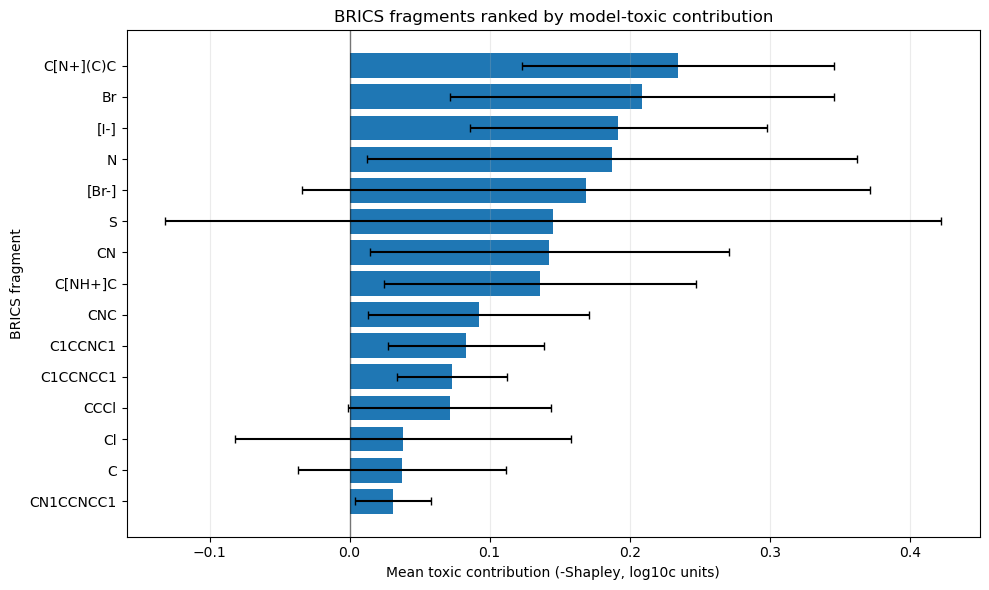

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'BRICS fragments ranked by model-toxic contribution'}, xlabel='Mean toxic contribution (-Shapley, log10c units)', ylabel='BRICS fragment'>)

In [9]:
# ===== Ranked fragment tables + bar chart (reads saved POPULATION artifacts) =====
# Pure pandas/matplotlib: run this locally without a GPU, straight from the CSVs.
from pathlib import Path


def latest_brics_run_dir():
    base = PROJECT_ROOT / "outputs" / "reports" / "brics_fragment_analysis"
    runs = sorted(p for p in base.glob("*/") if (p / "population" / "contributions.csv").exists())
    if not runs:
        raise FileNotFoundError(
            "No saved population contributions found. Run the compute cell (on the GPU server) first."
        )
    return runs[-1]


run_dir = LATEST_BRICS_RUN_DIR if "LATEST_BRICS_RUN_DIR" in dir() else latest_brics_run_dir()
print(f"Loading from: {run_dir}")

population_contributions = pd.read_csv(run_dir / "population" / "contributions.csv")

# Summaries are pure pandas, so we recompute them here rather than reload them.
pop_summary, pop_toxic_per_atom, pop_toxic_raw, pop_context = summarize_brics_group_toxicity(
    population_contributions, min_occurrences=POPULATION_MIN_OCCURRENCES
)

print("Most model-toxic repeated BRICS fragments (per-atom normalized):")
display(pop_toxic_per_atom.head(20))
print("Most model-toxic repeated BRICS fragments (raw group contribution):")
display(pop_toxic_raw.head(20))
print("Most context-dependent repeated BRICS fragments (by Shapley std):")
display(pop_context.head(20))

plot_top_brics_groups(pop_toxic_per_atom, top_n=15)


Loading population contributions from: /home/vollmers/gnn-thesis/outputs/reports/brics_fragment_analysis/run_imported
Fragment occurrences carrying a known structural alert: 398 / 3,044 (13.1%)


/tmp/ipykernel_1979794/2021340891.py:200: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


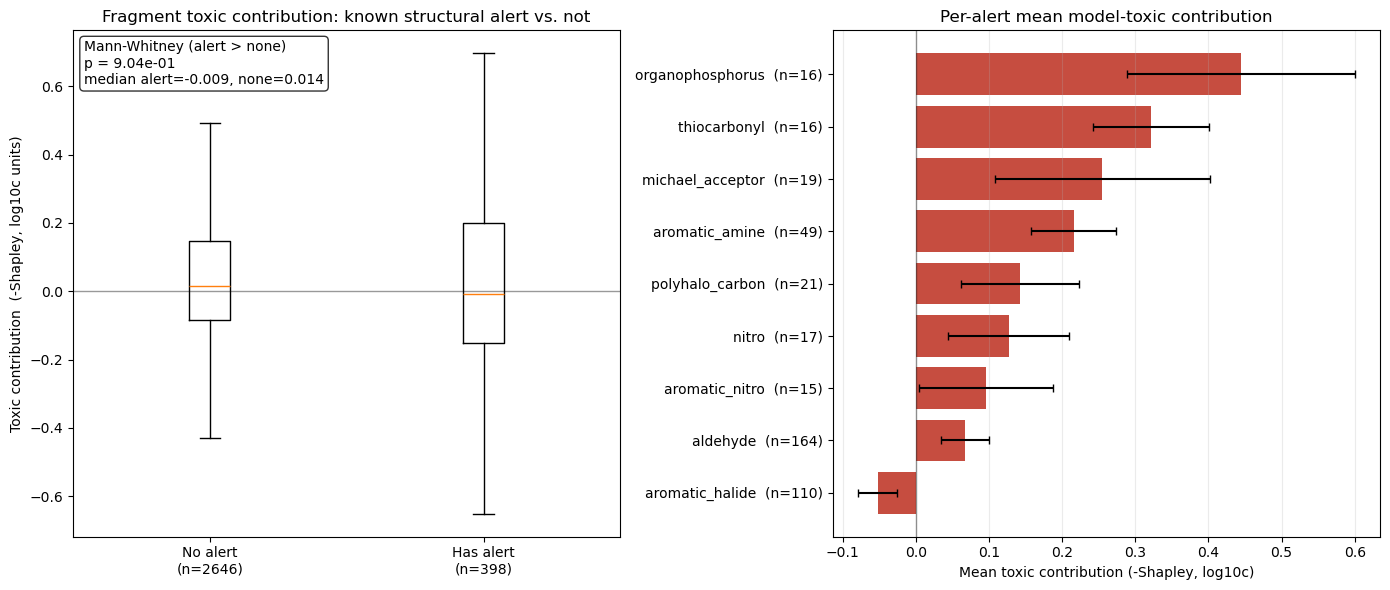


Per-alert mean model-toxic contribution (occurrence-weighted):


,toxicophore,n_occurrences,n_fragments,mean_value,median_value,sem_value
0,organophosphorus,16,11,0.444409,0.402371,0.156046
1,thiocarbonyl,16,11,0.321261,0.299988,0.078840
2,michael_acceptor,19,14,0.255079,0.320184,0.146919
3,aromatic_amine,49,38,0.215732,0.135829,0.058195
4,polyhalo_carbon,21,9,0.142387,0.003715,0.080986
5,nitro,17,9,0.126950,0.043386,0.082956
6,aromatic_nitro,15,7,0.095894,0.035852,0.091258
7,aldehyde,164,46,0.067519,-0.008949,0.033072
8,aromatic_halide,110,46,-0.052332,-0.103888,0.027254



Top alert-bearing fragments by mean toxic contribution:


,matched_toxicophores,fragment_smiles,n,n_molecules,mean_tox,mean_tox_per_atom
21,aldehyde,O=CC1CCCCc2[nH]c3cc4c(cc3c21)OCO4,1,1,2.628523,0.138343
30,aldehyde,O=CCCCCCCCCCF,1,1,2.326447,0.193871
37,"aldehyde, michael_acceptor",CC(=O)C(C=O)=C1SC=CS1,1,1,2.289211,0.208110
78,"aromatic_amine, organophosphorus",CN(C)P(=O)(N(C)C)n1ncnc1N,1,1,1.772017,0.126573
108,aromatic_halide,N#Cc1cc(Cl)cc2[nH]cnc12,1,1,1.738873,0.144906
54,aromatic_amine,Nc1cn[nH]c1,1,1,1.474180,0.245697
139,"nitro, aromatic_nitro",O=[N+]([O-])c1cccc2[nH]cnc12,1,1,1.316701,0.109725
33,aldehyde,O=CCF,1,1,1.287279,0.321820
147,organophosphorus,NC=CP(=O)(Cl)Cl,1,1,1.071523,0.153075
171,thiocarbonyl,S=C(c1ccccc1)N1CCOCC1,1,1,1.049936,0.074995


In [7]:
# =====================================================================
# Toxicophore validation  (reads saved POPULATION artifacts)
# Decoupled from the GPU passes: iterate on plots without recomputing Shapley.
# Central thesis claim: model-attributed toxic fragments align with known
# structural alerts.
# =====================================================================
from pathlib import Path


def latest_brics_run_dir():
    base = PROJECT_ROOT / "outputs" / "reports" / "brics_fragment_analysis"
    runs = sorted(p for p in base.glob("*/") if (p / "population" / "contributions.csv").exists())
    if not runs:
        raise FileNotFoundError(
            "No saved population contributions found. Run the population+showcase cell first."
        )
    return runs[-1]


run_dir = LATEST_BRICS_RUN_DIR if "LATEST_BRICS_RUN_DIR" in dir() else latest_brics_run_dir()
print(f"Loading population contributions from: {run_dir}")

population_contributions = pd.read_csv(run_dir / "population" / "contributions.csv")
annotated = annotate_toxicophores(population_contributions)

n_alert = int(annotated["is_toxicophore"].sum())
print(
    f"Fragment occurrences carrying a known structural alert: "
    f"{n_alert:,} / {len(annotated):,} ({annotated['is_toxicophore'].mean():.1%})"
)

# --- Main validation figure + per-alert table ---
fig, axes, per_alert = plot_toxicophore_validation(
    annotated, value_col="tox_shapley_log10c", min_alert_occurrences=POPULATION_MIN_OCCURRENCES
)
print("\nPer-alert mean model-toxic contribution (occurrence-weighted):")
display(per_alert)

# --- Which concrete fragments drive each alert ---
top_alert_fragments = (
    annotated[annotated["is_toxicophore"]]
    .groupby(["matched_toxicophores", "fragment_smiles"], dropna=False)
    .agg(
        n=("tox_shapley_log10c", "size"),
        n_molecules=("row_id", "nunique"),
        mean_tox=("tox_shapley_log10c", "mean"),
        mean_tox_per_atom=("tox_shapley_per_atom_log10c", "mean"),
    )
    .reset_index()
    .sort_values("mean_tox", ascending=False)
)
print("\nTop alert-bearing fragments by mean toxic contribution:")
display(top_alert_fragments.head(25))
